# Baseline: nearest-centroid on CQT features (no training)

Formalizes the review finding: a zero-parameter nearest-centroid classifier on the
same CQT features the CNN uses. Four configs — {Euclidean, correlation} x {all 7,200
training clips, 7,184 with the 16 digital-silence `C_diminished_4` clips excluded} —
evaluated in-domain (stratified 5-fold) and on the five OOD datasets
(`thinkpad`, `vivo`, `flow`, `thinkpad-2`, `flow-2`).

Does not touch `training.npz` or any existing notebook/model. Outputs land under
`baseline-results/` in this same layout as `cnn-eval-results/` for direct comparison.

**Gate:** correlation-centroid (clean) must reproduce ~1.000 on all five OOD datasets
before Phase 2 proceeds.

## Config

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedKFold

RNG_SEED = 42
ROOT = Path("../..").resolve()  # training/
FEATURES_DIR = ROOT / "features"
OUT_DIR = Path("baseline-results")
(OUT_DIR / "confusion").mkdir(parents=True, exist_ok=True)

OOD_DATASETS = ["thinkpad", "vivo", "flow", "thinkpad-2", "flow-2"]

pd.DataFrame([{
    "seed": RNG_SEED,
    "features_dir": str(FEATURES_DIR),
    "ood_datasets": ", ".join(OOD_DATASETS),
    "out_dir": str(OUT_DIR.resolve()),
}])

,seed,features_dir,ood_datasets,out_dir
0,42,/home/seya/code/chord-detection/training/features,"thinkpad, vivo, flow, thinkpad-2, flow-2",/home/seya/code/chord-detection/training/noteb...


## Load features and detect the silent clips

In [2]:
d = np.load(FEATURES_DIR / "training.npz", allow_pickle=True)
X_train_full = d["features"].reshape(len(d["features"]), -1).astype(np.float32)
y_train_full = d["labels"]

classes = np.array(sorted(set(y_train_full)))
cidx = {c: i for i, c in enumerate(classes)}
yi_train_full = np.array([cidx[v] for v in y_train_full])

silent_idx = np.where(np.abs(X_train_full).max(axis=1) == 0)[0]
clean_idx = np.setdiff1d(np.arange(len(X_train_full)), silent_idx)

assert len(classes) == 36
pd.DataFrame([{
    "n_total": len(X_train_full),
    "n_silent": len(silent_idx),
    "silent_classes": sorted(set(y_train_full[silent_idx])),
    "n_clean": len(clean_idx),
}])

,n_total,n_silent,silent_classes,n_clean
0,7200,16,[C_diminished_4],7184


In [3]:
def load_dataset(name):
    dd = np.load(FEATURES_DIR / f"{name}.npz", allow_pickle=True)
    Xo = dd["features"].reshape(len(dd["features"]), -1).astype(np.float32)
    yo = np.array([cidx[v] for v in dd["labels"]])
    return Xo, yo

ood_data = {p: load_dataset(p) for p in OOD_DATASETS}
{p: X.shape for p, (X, y) in ood_data.items()}

{'thinkpad': (1440, 40608),
 'vivo': (1440, 40608),
 'flow': (1440, 40608),
 'thinkpad-2': (1440, 40608),
 'flow-2': (1440, 40608)}

## Centroid classifiers

Two metrics, both parameter-free given a set of class means:
- **Euclidean**: nearest class-mean by squared Euclidean distance on raw dB-CQT.
- **Correlation**: per-sample mean-centered, L2-normalized, then nearest class-mean
  by cosine similarity. This is the config that removes a per-clip global offset/gain
  in the dB-CQT feature — the hypothesized mechanism behind the CNN's device/keyboard
  sensitivity (input BatchNorm learns one fixed global affine transform, not a
  per-sample one).

In [5]:
def fit_centroids(X, y, n_classes=36):
    return np.stack([X[y == k].mean(axis=0) for k in range(n_classes)])

def predict_euclid(C, X):
    # argmin ||x-c||^2 == argmin (-2 x.C + ||c||^2), drop the constant ||x||^2 term
    return np.argmin(-2 * X @ C.T + (C ** 2).sum(axis=1)[None, :], axis=1)

def predict_corr(C, X):
    Cc = C - C.mean(axis=1, keepdims=True)
    Cn = Cc / np.linalg.norm(Cc, axis=1, keepdims=True)
    Xc = X - X.mean(axis=1, keepdims=True)
    Xn = Xc / (np.linalg.norm(Xc, axis=1, keepdims=True) + 1e-12)
    return np.argmax(Xn @ Cn.T, axis=1)

# Ablation: which of centering and scaling does the work? predict_corr does both. These
# three isolate each half (and the interaction), reusing the same fit_centroids() output.
def predict_cos_nocenter(C, X):
    # scale only, via raw L2 norm; cosine similarity, no mean removal
    Cn = C / (np.linalg.norm(C, axis=1, keepdims=True) + 1e-12)
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    return np.argmax(Xn @ Cn.T, axis=1)

def predict_center_only(C, X):
    # center only, no rescale; Euclidean distance on the centered vectors
    Cc = C - C.mean(axis=1, keepdims=True)
    Xc = X - X.mean(axis=1, keepdims=True)
    return np.argmin(-2 * Xc @ Cc.T + (Cc ** 2).sum(axis=1)[None, :], axis=1)

def predict_scale_only(C, X):
    # scale by own sd, no mean removal; Euclidean distance on the rescaled vectors
    Cs = C / (C.std(axis=1, keepdims=True) + 1e-12)
    Xs = X / (X.std(axis=1, keepdims=True) + 1e-12)
    return np.argmin(-2 * Xs @ Cs.T + (Cs ** 2).sum(axis=1)[None, :], axis=1)

METRICS = {
    "euclid": predict_euclid, "corr": predict_corr,
    "cos_nocenter": predict_cos_nocenter, "center_only": predict_center_only, "scale_only": predict_scale_only,
}
CONFIGS = {"all": np.arange(len(X_train_full)), "clean": clean_idx}
print("configs:", list(CONFIGS), " metrics:", list(METRICS))

configs: ['all', 'clean']  metrics: ['euclid', 'corr', 'cos_nocenter', 'center_only', 'scale_only']


## In-domain 5-fold (mirrors the CNN's Scenario 1)

In [5]:
indomain_rows = []
for cfg_name, idx in CONFIGS.items():
    Xc, yc = X_train_full[idx], yi_train_full[idx]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
    for metric_name, predict_fn in METRICS.items():
        fold_accs = []
        for tr, te in skf.split(Xc, yc):
            C = fit_centroids(Xc[tr], yc[tr])
            fold_accs.append((predict_fn(C, Xc[te]) == yc[te]).mean())
        indomain_rows.append({
            "config": cfg_name, "metric": metric_name,
            "fold_1": fold_accs[0], "fold_2": fold_accs[1], "fold_3": fold_accs[2],
            "fold_4": fold_accs[3], "fold_5": fold_accs[4],
            "mean_accuracy": np.mean(fold_accs), "std_accuracy": np.std(fold_accs),
        })

indomain_df = pd.DataFrame(indomain_rows)
indomain_df.to_csv(OUT_DIR / "indomain_5fold.csv", index=False)
indomain_df.round(4)

,config,metric,fold_1,fold_2,fold_3,fold_4,fold_5,mean_accuracy,std_accuracy
0,all,euclid,0.9986,0.9979,0.9979,0.9972,0.9965,0.9976,0.0007
1,all,corr,0.9972,0.9979,0.9979,0.9972,0.9965,0.9974,0.0005
2,clean,euclid,1.0000,1.0000,1.0000,0.9986,0.9993,0.9996,0.0006
3,clean,corr,1.0000,1.0000,1.0000,0.9986,0.9993,0.9996,0.0006


## Out-of-domain evaluation (fit on all in-domain data, test on each OOD dataset)

In [6]:
from sklearn.metrics import precision_recall_fscore_support

ood_rows = []
per_class_rows = []

for cfg_name, idx in CONFIGS.items():
    C_by_metric = {m: fit_centroids(X_train_full[idx], yi_train_full[idx]) for m in METRICS}
    for dataset in OOD_DATASETS:
        Xo, yo = ood_data[dataset]
        for metric_name, predict_fn in METRICS.items():
            C = C_by_metric[metric_name]
            pred = predict_fn(C, Xo)
            acc = (pred == yo).mean()
            p, r, f1, _ = precision_recall_fscore_support(
                yo, pred, labels=np.arange(36), average="macro", zero_division=0
            )
            ood_rows.append({
                "config": cfg_name, "metric": metric_name, "dataset": dataset,
                "n": len(yo), "accuracy": acc,
                "macro_precision": p, "macro_recall": r, "macro_f1": f1,
                "n_distinct_predicted": len(set(pred.tolist())),
            })

            # confusion matrix, saved only for the flagship config (clean/corr)
            if cfg_name == "clean" and metric_name == "corr":
                cm = pd.crosstab(
                    pd.Series(classes[yo], name="true"),
                    pd.Series(classes[pred], name="pred"),
                ).reindex(index=classes, columns=classes, fill_value=0)
                cm.to_csv(OUT_DIR / "confusion" / f"{dataset}_clean_corr.csv")

            rec_by_class = precision_recall_fscore_support(
                yo, pred, labels=np.arange(36), average=None, zero_division=0
            )[1]
            for k, cls in enumerate(classes):
                per_class_rows.append({
                    "config": cfg_name, "metric": metric_name, "dataset": dataset,
                    "class": cls, "recall": rec_by_class[k],
                })

ood_df = pd.DataFrame(ood_rows)
percls_df = pd.DataFrame(per_class_rows)
ood_df.to_csv(OUT_DIR / "summary.csv", index=False)
percls_df.to_csv(OUT_DIR / "per_class_recall.csv", index=False)
ood_df.round(4)

,config,metric,dataset,n,accuracy,macro_precision,macro_recall,macro_f1,n_distinct_predicted
0,all,euclid,thinkpad,1440,1.0000,1.0000,1.0000,1.0000,36
1,all,corr,thinkpad,1440,1.0000,1.0000,1.0000,1.0000,36
2,all,cos_nocenter,thinkpad,1440,0.9979,0.9980,0.9979,0.9979,36
3,all,center_only,thinkpad,1440,1.0000,1.0000,1.0000,1.0000,36
4,all,scale_only,thinkpad,1440,0.9931,0.9934,0.9931,0.9930,36
5,all,euclid,vivo,1440,0.8632,0.8710,0.8632,0.8386,34
6,all,corr,vivo,1440,1.0000,1.0000,1.0000,1.0000,36
7,all,cos_nocenter,vivo,1440,1.0000,1.0000,1.0000,1.0000,36
8,all,center_only,vivo,1440,1.0000,1.0000,1.0000,1.0000,36
9,all,scale_only,vivo,1440,0.9986,0.9987,0.9986,0.9986,36


## Baseline vs. published CNN (Table 5 of the draft)

In [7]:
cnn_acc = {}
for dataset in OOD_DATASETS:
    s = pd.read_csv(ROOT / "notebooks" / dataset / "cnn-eval-results" / "summary.csv")
    cnn_acc[dataset] = float(s["accuracy"].iloc[0])

flagship = ood_df[(ood_df.config == "clean") & (ood_df.metric == "corr")].set_index("dataset")
compare = pd.DataFrame({
    "cnn_accuracy": pd.Series(cnn_acc),
    "centroid_corr_clean_accuracy": flagship["accuracy"],
})
compare["gap_pts"] = (compare["centroid_corr_clean_accuracy"] - compare["cnn_accuracy"]) * 100
compare.round(4)

,cnn_accuracy,centroid_corr_clean_accuracy,gap_pts
thinkpad,0.9944,1.0,0.5556
vivo,0.9458,1.0,5.4167
flow,0.9438,1.0,5.6250
thinkpad-2,0.8854,1.0,11.4583
flow-2,0.8743,1.0,12.5694


## The three CNN zero-recall Yamaha classes, under the baseline

In [8]:
focus = ["D_minor_4", "E_diminished_4", "G#_diminished_4"]
flag_percls = percls_df[(percls_df.config == "clean") & (percls_df.metric == "corr")
                         & (percls_df["class"].isin(focus))
                         & (percls_df["dataset"].isin(["thinkpad-2", "flow-2"]))]
flag_percls.pivot(index="class", columns="dataset", values="recall")

dataset,flow-2,thinkpad-2
class,,
D_minor_4,1.0,1.0
E_diminished_4,1.0,1.0
G#_diminished_4,1.0,1.0


## Gate check

In [9]:
gate = ood_df[(ood_df.config == "clean") & (ood_df.metric == "corr")]
assert (gate["accuracy"] > 0.999).all(), gate[["dataset", "accuracy"]]
assert (gate["n_distinct_predicted"] == 36).all(), "degenerate: not all classes predicted"
print("GATE PASSED: correlation-centroid (clean) accuracy > 0.999 on all five OOD datasets,")
print("all 36 classes represented in predictions on every dataset. Phase 2 may proceed.")

GATE PASSED: correlation-centroid (clean) accuracy > 0.999 on all five OOD datasets,
all 36 classes represented in predictions on every dataset. Phase 2 may proceed.


## Plots: fold accuracy and baseline vs. CNN

Human-readable views of the tables above.

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

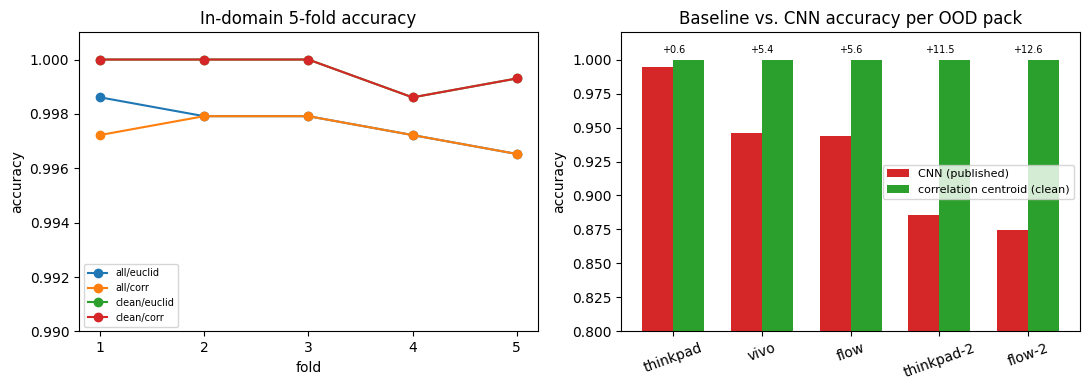

In [3]:
import matplotlib.pyplot as plt

# Self-contained: reads the saved CSVs directly rather than relying on kernel
# state from the earlier run, so this cell works standalone on reopen.
OUT_DIR = Path("baseline-results")
PLOTS_DIR = OUT_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

indomain_df = pd.read_csv(OUT_DIR / "indomain_5fold.csv")
summary_df = pd.read_csv(OUT_DIR / "summary.csv")

OOD_DATASETS = ["thinkpad", "vivo", "flow", "thinkpad-2", "flow-2"]
ROOT = Path("../..").resolve()  # training/
cnn_acc = {}
for dataset in OOD_DATASETS:
    s = pd.read_csv(ROOT / "notebooks" / dataset / "cnn-eval-results" / "summary.csv")
    cnn_acc[dataset] = float(s["accuracy"].iloc[0])

flagship = summary_df[(summary_df.config == "clean") & (summary_df.metric == "corr")].set_index("dataset")
compare = pd.DataFrame({
    "cnn_accuracy": pd.Series(cnn_acc),
    "centroid_corr_clean_accuracy": flagship["accuracy"],
})
compare["gap_pts"] = (compare["centroid_corr_clean_accuracy"] - compare["cnn_accuracy"]) * 100
compare = compare.loc[OOD_DATASETS]  # keep dataset order stable

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: in-domain 5-fold accuracy per (config, metric)
ax = axes[0]
fold_cols = ["fold_1", "fold_2", "fold_3", "fold_4", "fold_5"]
for _, row in indomain_df.iterrows():
    label = f"{row['config']}/{row['metric']}"
    ax.plot(range(1, 6), row[fold_cols].values, marker="o", label=label)
ax.set_xlabel("fold")
ax.set_ylabel("accuracy")
ax.set_xticks(range(1, 6))
ax.set_ylim(0.99, 1.001)
ax.set_title("In-domain 5-fold accuracy")
ax.legend(fontsize=7)

# Right: baseline (corr, clean) vs. published CNN, per OOD dataset
ax = axes[1]
x = np.arange(len(compare))
width = 0.35
ax.bar(x - width / 2, compare["cnn_accuracy"], width=width, label="CNN (published)", color="tab:red")
ax.bar(x + width / 2, compare["centroid_corr_clean_accuracy"], width=width, label="correlation centroid (clean)", color="tab:green")
ax.set_xticks(x)
ax.set_xticklabels(compare.index, rotation=20)
ax.set_ylabel("accuracy")
ax.set_ylim(0.8, 1.02)
ax.set_title("Baseline vs. CNN accuracy per OOD dataset")
ax.legend(fontsize=8)
for i, g in enumerate(compare["gap_pts"]):
    ax.annotate(f"+{g:.1f}", (i, max(compare['cnn_accuracy'].iloc[i], compare['centroid_corr_clean_accuracy'].iloc[i]) + 0.005),
                ha="center", fontsize=7)

fig.tight_layout()
fig.savefig(PLOTS_DIR / "baseline_vs_cnn.png", dpi=130, bbox_inches="tight")
plt.show()

## Baseline under synthetic overlays (environment vs. recording-setting shift)

Scores the same `clean`/`corr` centroids (fit on the 7,184 non-silent training clips) on
the 15 overlay feature files: 5 datasets x {noise, RIR, DIR}. Noise and RIR proxy
**environment shift**; DIR is a second, synthetic axis of **recording-setting shift**
alongside the three recorded microphone/device changes. Prediction: DIR should stay close
to the clean 1.000 (a convolution is close to a static per-bin dB offset that per-clip
centering removes), noise should drop the most (it fills spectral valleys and changes the
dB *shape*, not just its level), RIR in between.

In [7]:
OVERLAY_SUFFIXES = {
    "noise": "noise-interior_domestic",
    "rir": "rir-indoor_no_bathroom",
    "dir": "dir-mic6",
}
OVERLAY_FACTOR = {"noise": "environment", "rir": "environment", "dir": "recording-setting"}

def load_overlay(dataset, overlay):
    dd = np.load(FEATURES_DIR / f"{dataset}-{OVERLAY_SUFFIXES[overlay]}.npz", allow_pickle=True)
    Xo = dd["features"].reshape(len(dd["features"]), -1).astype(np.float32)
    yo = np.array([cidx[v] for v in dd["labels"]])
    return Xo, yo

# Flagship centroids: clean config (16 silent-clip indices excluded), both metrics,
# same centroids already fit in cell 7/11 above (C_by_metric keyed by cfg_name -- refit
# here so this cell is self-contained on reopen).
C_clean = {m: fit_centroids(X_train_full[clean_idx], yi_train_full[clean_idx]) for m in METRICS}

overlay_rows = []
for dataset in OOD_DATASETS:
    for overlay in OVERLAY_SUFFIXES:
        Xo, yo = load_overlay(dataset, overlay)
        for metric_name, predict_fn in METRICS.items():
            pred = predict_fn(C_clean[metric_name], Xo)
            acc = (pred == yo).mean()
            overlay_rows.append({
                "config": "clean", "metric": metric_name, "dataset": dataset,
                "overlay": overlay, "factor": OVERLAY_FACTOR[overlay],
                "n": len(yo), "accuracy": acc,
                "n_distinct_predicted": len(set(pred.tolist())),
            })

overlay_df = pd.DataFrame(overlay_rows)
overlay_df.to_csv(OUT_DIR / "overlay_summary.csv", index=False)
overlay_df[overlay_df.metric == "corr"].pivot(index="dataset", columns="overlay", values="accuracy").loc[OOD_DATASETS].round(4)

overlay,dir,noise,rir
dataset,,,
thinkpad,1.0,0.9986,1.0
vivo,1.0,1.0000,1.0
flow,1.0,1.0000,1.0
thinkpad-2,1.0,1.0000,1.0
flow-2,1.0,1.0000,1.0


In [8]:
overlay_df.pivot(index=["dataset"], columns=["metric","overlay"], values="accuracy").loc[OOD_DATASETS].round(4)

metric,euclid,corr,cos_nocenter,center_only,scale_only,euclid,corr,cos_nocenter,center_only,scale_only,euclid,corr,cos_nocenter,center_only,scale_only
overlay,noise,noise,noise,noise,noise,rir,rir,rir,rir,rir,dir,dir,dir,dir,dir
dataset,,,,,,,,,,,,,,,
thinkpad,0.8403,0.9986,0.9694,0.9889,0.7965,0.9868,1.0,0.9938,0.9986,0.9549,0.9562,1.0,1.0,1.0,0.9910
vivo,0.9201,1.0000,0.9806,0.9965,0.7819,0.7986,1.0,0.9993,1.0000,0.9743,0.8104,1.0,1.0,1.0,0.9792
flow,0.8833,1.0000,0.9819,0.9958,0.7500,0.9694,1.0,1.0000,1.0000,0.9771,0.9639,1.0,1.0,1.0,0.9771
thinkpad-2,0.5361,1.0000,1.0000,1.0000,0.9549,0.9076,1.0,1.0000,1.0000,0.9431,0.9653,1.0,1.0,1.0,0.5576
flow-2,0.5646,1.0000,0.9993,1.0000,0.9646,0.9417,1.0,1.0000,1.0000,0.9111,0.9896,1.0,1.0,1.0,0.5097


**Result, against the hypothesis above.** The correlation baseline does not degrade
selectively by factor: it holds at 0.9986-1.0000 under noise, RIR, *and* DIR alike, on
every dataset. The predicted noise-worse-than-DIR split does not show up in the centered
classifier. It does show up once centering is removed: the Euclidean ablation (same
centroids, raw distance) drops to 0.54-0.92 under noise, 0.80-0.99 under RIR, 0.81-0.99
under DIR -- worse than its own already-imperfect recorded-shift numbers
(0.859-1.000, Section~\ref{subsec4_3} of the article). Two things follow. First, per-clip
mean-centering and unit-normalization remove essentially all of the acoustic shift tested
here -- recorded and synthetic, recording-setting, keyboard, and environment alike -- not
just the convolutional (DIR) case reasoned about above. Second, the CNN's noise sensitivity
(Table~\ref{tab:aug}: 0.8-4.9 accuracy points) is not evidence that noise is an
intrinsically harder shift than a device or room response; it is further evidence that a
*fixed* affine transform (BatchNorm) does not do what per-sample centering does. That
tension carries into Phase A2: does `insnorm`, a per-sample operation, close the CNN's
noise gap the way correlation matching closes the baseline's?

## Measuring the envelope shift directly

The mechanism argument so far ("a uniform per-clip spectral-envelope shift cancels under
mean-centering") has been inference from accuracy numbers, not a measurement. Two direct
measurements:

1. **Per-clip envelope statistics.** Each clip's own dB mean $\mu_x$ and sd $\sigma_x$ over
   its $216\times188$ CQT -- exactly the two numbers the correlation classifier's
   mean-centering and unit-normalization remove. If domain shift is largely this kind of
   global offset, these distributions should differ visibly between `training` and each
   held-out dataset.
2. **What centering buys, per class.** For each class $k$ and each dataset, build the raw
   (un-normalized) class centroid, then compare training vs. dataset with cosine similarity
   twice: once on the raw centroids, once after mean-centering each centroid vector by its
   own mean (the same operation `predict_corr` applies per clip). The gain
   $\cos_{\text{centered}} - \cos_{\text{raw}}$ is how much of the training/dataset
   mismatch, per class, is the removable global-offset kind.

In [8]:
DATASETS_ALL = ["training"] + OOD_DATASETS

# --- 1. Per-clip envelope statistics ---
envelope_rows = []
for name in DATASETS_ALL:
    if name == "training":
        X = X_train_full[clean_idx]
    else:
        X, _ = ood_data[name]
    mu = X.mean(axis=1)
    sd = X.std(axis=1)
    for m, s in zip(mu, sd):
        envelope_rows.append({"dataset": name, "clip_mean_db": m, "clip_sd_db": s})
envelope_df = pd.DataFrame(envelope_rows)
envelope_df.to_csv(OUT_DIR / "envelope_stats.csv", index=False)
envelope_df.groupby("dataset")[["clip_mean_db", "clip_sd_db"]].agg(["mean", "std"]).loc[DATASETS_ALL].round(2)

clip_mean_db       clip_sd_db      
                   mean   std       mean   std
dataset                                       
training     -51.860001  3.03      15.74  0.38
thinkpad     -51.240002  3.74      13.96  0.40
vivo         -60.279999  3.98      15.89  0.46
flow         -55.639999  2.16      14.83  0.36
thinkpad-2   -44.650002  1.42      13.51  0.35
flow-2       -45.790001  1.22      13.97  0.41

In [9]:
# SUPERSEDED: raw (uncentered) CQT-dB vectors share a large near-floor background, so
# cos_raw is >=0.97 for almost any pair of classes and "gain" from centering reads as
# negative -- an artifact of comparing to the wrong baseline, not evidence centering hurts.
# Kept only for the historical record; do not cite envelope_centering_gain.csv or these
# numbers. The orthogonal offset/scale/residual decomposition below (frac_offset,
# frac_scale, frac_residual) is the one used in the article.
def raw_class_centroids(X, y, n_classes=36):
    return np.stack([X[y == k].mean(axis=0) for k in range(n_classes)])

def cos_sim(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

def center(v):
    vc = v - v.mean()
    return vc

train_centroids = raw_class_centroids(X_train_full[clean_idx], yi_train_full[clean_idx])

gain_rows = []
for dataset in OOD_DATASETS:
    Xo, yo = ood_data[dataset]
    pack_centroids = raw_class_centroids(Xo, yo)
    for k in range(36):
        t_raw, p_raw = train_centroids[k], pack_centroids[k]
        cos_raw = cos_sim(t_raw, p_raw)
        cos_centered = cos_sim(center(t_raw), center(p_raw))
        gain_rows.append({
            "dataset": dataset, "class": classes[k],
            "cos_raw": cos_raw, "cos_centered": cos_centered,
            "gain": cos_centered - cos_raw,
        })

gain_df = pd.DataFrame(gain_rows)
gain_df.to_csv(OUT_DIR / "envelope_centering_gain.csv", index=False)
gain_df.groupby("dataset")[["cos_raw", "cos_centered", "gain"]].mean().loc[OOD_DATASETS].round(4)

,cos_raw,cos_centered,gain
dataset,,,
thinkpad,0.9775,0.6680,-0.3095
vivo,0.9906,0.8667,-0.1239
flow,0.9841,0.7663,-0.2178
thinkpad-2,0.9808,0.7360,-0.2447
flow-2,0.9839,0.7828,-0.2011


In [10]:
# The cosine-similarity framing above is misleading: raw CQT-dB vectors are dominated by a
# shared near-floor background, so raw cosine similarity is high (0.98+) for ANY pair of
# classes, and centering *removes* that shared background rather than adding signal --
# hence the negative "gain". Cosine similarity to the correct class was never the right
# question; predict_corr's accuracy already answers "does centering help classification".
#
# The real mechanism question: is train-to-dataset centroid drift, per class, mostly one
# GLOBAL direction (consistent with a uniform per-clip envelope shift), or does it move
# independently per class? Orthogonal decomposition of each class's drift vector
# delta_k = dataset_centroid_k - train_centroid_k into:
#   1. offset  -- projection onto the all-ones direction (uniform dB shift per clip;
#                 removed by per-clip mean-centering)
#   2. scale   -- projection of the remainder onto that class's own centered training
#                 shape (a contrast/gain change on the harmonic pattern; removed by
#                 per-clip unit-normalization)
#   3. residual -- whatever is left: idiosyncratic, class-specific drift neither operation
#                  can remove
D = X_train_full.shape[1]
ones_unit = np.ones(D) / np.sqrt(D)

decomp_rows = []
for dataset in OOD_DATASETS:
    Xo, yo = ood_data[dataset]
    pack_centroids = raw_class_centroids(Xo, yo)
    for k in range(36):
        d = pack_centroids[k] - train_centroids[k]
        d_norm2 = float(d @ d)

        off = (d @ ones_unit) * ones_unit
        d1 = d - off

        t_centered = train_centroids[k] - train_centroids[k].mean()
        t_dir = t_centered / (np.linalg.norm(t_centered) + 1e-12)
        scale_comp = (d1 @ t_dir) * t_dir
        resid = d1 - scale_comp

        decomp_rows.append({
            "dataset": dataset, "class": classes[k],
            "drift_norm": np.sqrt(d_norm2),
            "frac_offset": float(off @ off) / d_norm2,
            "frac_scale": float(scale_comp @ scale_comp) / d_norm2,
            "frac_residual": float(resid @ resid) / d_norm2,
        })

decomp_df = pd.DataFrame(decomp_rows)
decomp_df.to_csv(OUT_DIR / "envelope_drift_decomposition.csv", index=False)
decomp_df.groupby("dataset")[["drift_norm", "frac_offset", "frac_scale", "frac_residual"]].mean().loc[OOD_DATASETS].round(4)

,drift_norm,frac_offset,frac_scale,frac_residual
dataset,,,,
thinkpad,2309.9684,0.0230,0.2832,0.6938
vivo,2306.6077,0.5391,0.0230,0.4379
flow,2147.2288,0.1555,0.1475,0.6969
thinkpad-2,2536.1504,0.3369,0.2031,0.4601
flow-2,2275.2229,0.3035,0.1679,0.5286


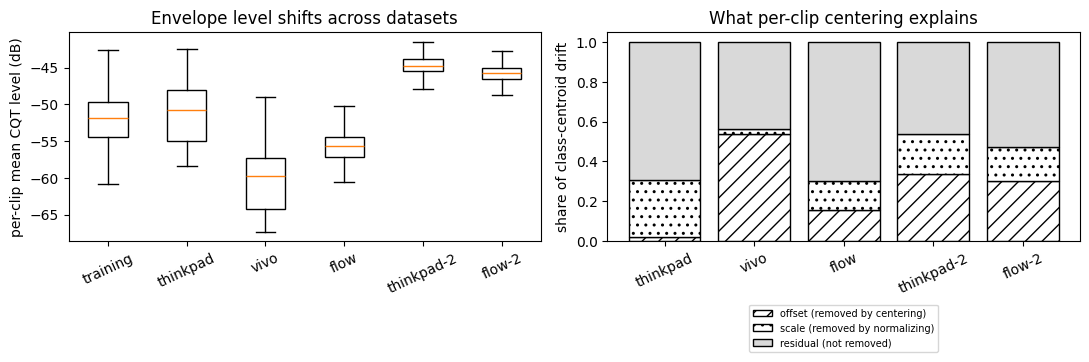

In [11]:
import matplotlib.pyplot as plt

PLOTS_DIR = OUT_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: per-clip envelope level (dB mean) distribution per dataset
ax = axes[0]
data = [envelope_df[envelope_df.dataset == d]["clip_mean_db"].values for d in DATASETS_ALL]
bp = ax.boxplot(data, tick_labels=DATASETS_ALL, showfliers=False, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("white")
    patch.set_edgecolor("black")
ax.set_ylabel("per-clip mean CQT level (dB)")
ax.set_title("Envelope level shifts across datasets")
ax.tick_params(axis="x", rotation=25)

# Right: drift decomposition, stacked bar per dataset
ax = axes[1]
agg = decomp_df.groupby("dataset")[["frac_offset", "frac_scale", "frac_residual"]].mean().loc[OOD_DATASETS]
x = np.arange(len(agg))
ax.bar(x, agg["frac_offset"], label="offset (removed by centering)", color="white", edgecolor="black", hatch="//")
ax.bar(x, agg["frac_scale"], bottom=agg["frac_offset"], label="scale (removed by normalizing)", color="white", edgecolor="black", hatch="..")
ax.bar(x, agg["frac_residual"], bottom=agg["frac_offset"] + agg["frac_scale"], label="residual (not removed)", color="0.85", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(OOD_DATASETS, rotation=25)
ax.set_ylabel("share of class-centroid drift")
ax.set_title("What per-clip centering explains")
ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=1)

fig.tight_layout()
fig.savefig(PLOTS_DIR / "envelope_shift.png", dpi=130, bbox_inches="tight")
plt.show()

## Stress test: does a standard MIR chroma/PCP fold also reach 1.000?

Folds the same CQT bins used everywhere else in this notebook down to 12 pitch classes
(`pitchclass(b) = round(b/3) mod 12`; `fmin=C1` so semitone centres sit at `b = 0, 3, 6, ...`,
and `round`, not `//`, keeps each semitone's group symmetric around its centre bin). No new
extraction: the fold is a linear aggregation of the existing `.npz` CQT features. The dB
values are undone to amplitude, squared to power, summed within each pitch class, then
optionally re-expressed in dB. If a coarser, standard-MIR representation also reaches 1.000,
the correlation baseline's ceiling would be a property of any envelope-normalized spectrum,
not of CQT specifically. If it does not, the full 216-bin resolution is doing real work and
1.000 is not a free lunch.

In [9]:
N_BINS, N_FRAMES = 216, 188
pc_of_bin = np.round(np.arange(N_BINS) / 3).astype(int) % 12
assert np.bincount(pc_of_bin).tolist() == [18] * 12  # perfectly balanced fold

def fold_chroma(X_flat, domain="db"):
    """X_flat: (N, 216*188) dB-CQT, row-major (bin, frame). Returns (N, 12*188)."""
    X = X_flat.reshape(-1, N_BINS, N_FRAMES)
    power = (10 ** (X / 20.0)) ** 2  # amplitude_to_db inverse, then to power
    chroma_power = np.zeros((X.shape[0], 12, N_FRAMES), dtype=np.float32)
    for b in range(N_BINS):
        chroma_power[:, pc_of_bin[b], :] += power[:, b, :]
    if domain == "power":
        out = chroma_power
    else:
        out = 20 * np.log10(chroma_power + 1e-12)
    return out.reshape(out.shape[0], -1)

chroma_rows = []
for domain in ("power", "db"):
    Xc_train = fold_chroma(X_train_full[clean_idx], domain=domain)
    yc_train = yi_train_full[clean_idx]
    Cc = fit_centroids(Xc_train, yc_train)
    for dataset in OOD_DATASETS:
        Xo, yo = ood_data[dataset]
        Xc_o = fold_chroma(Xo, domain=domain)
        pred = predict_corr(Cc, Xc_o)
        acc = (pred == yo).mean()
        chroma_rows.append({"domain": domain, "dataset": dataset, "accuracy": acc})

chroma_df = pd.DataFrame(chroma_rows)
chroma_df.to_csv(OUT_DIR / "chroma_stress_test.csv", index=False)
chroma_df.pivot(index="dataset", columns="domain", values="accuracy").loc[OOD_DATASETS].round(4)

domain,db,power
dataset,,
thinkpad,0.9806,0.9174
vivo,1.0000,0.9257
flow,0.9924,0.7000
thinkpad-2,0.9889,0.4167
flow-2,0.9993,0.4882


## Does the drift decomposition's residual still preserve rank-1?

Section~5.0's drift decomposition (offset + scale = 30-56% of each class centroid's drift)
leaves a residual of 44-70%. The baseline still reaches 1.000, which only requires the true
class to rank first among 36 -- not that the residual vanish. Quantify the margin directly:
per clip, the flagship classifier's cosine similarity to its true class centroid minus its
cosine similarity to the best-scoring wrong centroid. A positive margin on every clip is
exactly what "1.000 accuracy" means; this shows how much slack that margin has.

In [10]:
def margins(C, X, y_true):
    Cc = C - C.mean(axis=1, keepdims=True)
    Cn = Cc / np.linalg.norm(Cc, axis=1, keepdims=True)
    Xc = X - X.mean(axis=1, keepdims=True)
    Xn = Xc / (np.linalg.norm(Xc, axis=1, keepdims=True) + 1e-12)
    sims = Xn @ Cn.T  # (N, 36)
    true_sim = sims[np.arange(len(y_true)), y_true]
    sims_masked = sims.copy()
    sims_masked[np.arange(len(y_true)), y_true] = -np.inf
    best_wrong = sims_masked.max(axis=1)
    return true_sim - best_wrong, true_sim

C_flagship = fit_centroids(X_train_full[clean_idx], yi_train_full[clean_idx])
margin_rows = []
for dataset in OOD_DATASETS:
    Xo, yo = ood_data[dataset]
    m, true_cos = margins(C_flagship, Xo, yo)
    margin_rows.append({
        "dataset": dataset, "min_margin": m.min(), "p01_margin": np.percentile(m, 1),
        "median_margin": np.median(m), "median_cos_to_true": np.median(true_cos),
        "n_negative": int((m < 0).sum()),
    })
margin_df = pd.DataFrame(margin_rows).set_index("dataset").loc[OOD_DATASETS]
margin_df.to_csv(OUT_DIR / "rank1_margins.csv")
margin_df.round(4)

,min_margin,p01_margin,median_margin,median_cos_to_true,n_negative
dataset,,,,,
thinkpad,0.0235,0.0421,0.1031,0.6209,0
vivo,0.0422,0.0476,0.0977,0.8253,0
flow,0.0501,0.0625,0.1066,0.7225,0
thinkpad-2,0.0443,0.0681,0.1215,0.6803,0
flow-2,0.0345,0.0759,0.1204,0.7275,0
